# Homework 9: Linear Regression

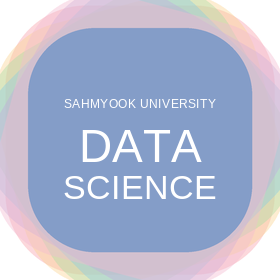

**Helpful Resource:**

- [Python Reference](http://data8.org/sp26/reference/): Cheat sheet of helpful array & table methods used in this data science course!

**Recommended Readings**: 

* [Correlation](https://inferentialthinking.com/chapters/15/1/Correlation.html)
* [The Regression Line](https://www.inferentialthinking.com/chapters/15/2/Regression_Line.html)
* [Method of Least Squares](https://www.inferentialthinking.com/chapters/15/3/Method_of_Least_Squares.html)
* [Least Squares Regression](https://www.inferentialthinking.com/chapters/15/4/Least_Squares_Regression.html)

In [ ]:
# Setup (run this first!)
!pip install -q otter-grader datascience
!git clone https://github.com/jihyungkim94/datascience.git 2>/dev/null || true
import os, json
os.chdir('/content/datascience/hw/hw09')
os.makedirs('tests', exist_ok=True)
with open('hw09.ipynb') as _f:
    _nb = json.load(_f)
for _name, _test in _nb['metadata']['otter']['tests'].items():
    with open('tests/' + _name + '.py', 'w') as _f:
        _f.write('OK_FORMAT = True\n\ntest = ' + repr(_test) + '\n')
import otter
grader = otter.Notebook('hw09.ipynb')
print('Ready! (16 tests loaded)')

Please complete this notebook by filling in the cells provided. **Before you begin, execute the cell below to setup the notebook by importing some helpful libraries.** Each time you start your server, you will need to execute this cell again.

Throughout this homework and all future ones, **please be sure to not re-assign variables throughout the notebook!** For example, if you use `max_temperature` in your answer to one question, do not reassign it later on. Otherwise, you will fail tests that you thought you were passing previously!

Directly sharing answers is not okay, but discussing problems with the course staff or with other students is encouraged.

You should start early so that you have time to get help if you're stuck.

---

The point breakdown for this assignment is given in the table below:
| Category | Points |
| --- | --- |
| Autograder (Coding questions) | 71 |
| Written (Visualization questions) | 29 |
| **Total** | 100 |

In [ ]:
# Run this cell to set up the notebook, but please don't change it.

import numpy as np
from datascience import * 

# These lines do some fancy plotting magic.
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', FutureWarning)
from datetime import datetime

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## 1. Linear Regression Setup

When performing linear regression, we need to compute several important quantities which will be used throughout our analysis. **Throughout this assignment, when asked to make a prediction, please assume we are predicting y from x, unless otherwise specified.** To help with our later analysis, we will begin by writing some of these functions and understanding what they can do for us.

---

**Question 1.1.** Define a function `standard_units` that converts a given array to standard units. **(3 points)**

*Hint:* You may find the `np.mean` and `np.std` functions helpful.


In [ ]:
def standard_units(data):
    ...

In [ ]:
grader.check("q1_1")

---

**Question 1.2.** Which of the following are true about standard units? Assume we have converted an array of data into standard units using the function above. **(5 points)**

1. The values of the data after being converted to standard units retain the same units as the original data.
2. The sum of all our data after being converted into standard units is 0.
3. The standard deviation of all our data after being converted into standard units is 1.
4. Adding a constant, C, to every value in our original data has no impact on the resultant data when converted to standard units.
5. Multiplying every value in our original data by a positive constant, C (>0), has no impact on the resultant data when converted to standard units.

Assign `standard_array` to an array of your selections, in increasing numerical order. For example, if you wanted to select options 1, 3, and 5,
you would assign `standard_array` to `make_array(1, 3, 5)`.


In [ ]:
standard_array = ...

In [ ]:
grader.check("q1_2")

---

**Question 1.3.** Define a function `correlation` that computes the correlation between `x` and `y`, which are 2 arrays of data in their original units. **(3 points)**

*Hint:* Feel free to use functions you have defined previously.


In [ ]:
def correlation(x, y):
    ...

In [ ]:
grader.check("q1_3")

---

**Question 1.4.** Which of the following are true about the correlation coefficient $r$? **(5 points)**

1. The correlation coefficient measures the strength of a linear relationship between two variables.
2. When looking at existing data, a correlation coefficient of 1.0 means that as one variable increases, the other variable always increases too.
3. The correlation coefficient is the slope of the regression line in standard units.
4. The correlation coefficient stays the same if we swap our x-axis and y-axis.
5. If we add a constant, C, to every value in our original data, our correlation coefficient will increase by the same C.

Assign `r_array` to an array of your selections, in increasing numerical order. For example, if you wanted to select options 1, 3, and 5,
you would assign `r_array` to `make_array(1, 3, 5)`.

Hint: Review [Section 15.1](https://inferentialthinking.com/chapters/15/1/Correlation.html#correlation) if you get stuck.


In [ ]:
r_array = ...

In [ ]:
grader.check("q1_4")

---

**Question 1.5.** Define a function `slope` that computes the slope of our line of best fit (to predict y given x). The function takes in x and y, which are two arrays of data in their original units. Assume we want to create a line of best fit in original units. **(3 points)**

*Hint:* Feel free to use functions you have defined previously.


In [ ]:
def slope(x, y):
    r = ...
    ...

In [ ]:
grader.check("q1_5")

---

**Question 1.6.** Which of the following are true about the slope of our line of best fit? Assume `x` refers to the value of one variable that we use to predict the value of `y`. **(5 points)**

1. In original units, the slope has the unit: unit of x / unit of y.
2. In standard units, the slope is unitless.
3. In original units, the slope is unchanged by swapping x and y.
4. In standard units, a slope of 1 means our data is perfectly linearly correlated.
5. In original units and standard units, the slope always has the same positive or negative sign.

Assign `slope_array` to an array of your selections, in increasing numerical order. For example, if you wanted to select options 1, 3, and 5,
you would assign `slope_array` to `make_array(1, 3, 5)`.


In [ ]:
slope_array = ...

In [ ]:
grader.check("q1_6")

---

**Question 1.7.** Define a function `intercept` that computes the intercept of our line of best fit (to predict y given x), given 2 arrays of data in original units. Assume we want to create a line of best fit in original units. **(3 points)**

*Hint:* Feel free to use functions you have defined previously.


In [ ]:
def intercept(x, y):
    ...

In [ ]:
grader.check("q1_7")

---

**Question 1.8.** Which of the following are true about the intercept of our line of best fit? Assume `x` refers to the value of one variable that we use to predict the value of `y`. **(5 points)**

1. In original units, the intercept has the same unit as the y values.
2. In original units, the intercept has the same unit as the x values.
3. In original units, the slope and intercept have the same unit.
4. In standard units, the intercept for the regression line is 0.
5. In original units and standard units, the intercept always has the same numerical value.

Assign `intercept_array` to an array of your selections, in increasing numerical order. For example, if you wanted to select options 1, 3, and 5,
you would assign `intercept_array` to `make_array(1, 3, 5)`.


In [ ]:
intercept_array = ...

In [ ]:
grader.check("q1_8")

---

**Question 1.9.** Define a function `predict` that takes in a table and 2 column names as strings, and returns an array of predictions. The predictions should be created using a fitted **regression line**. We are predicting `col2` from `col1`, both in original units. **(5 points)**

*Hint 1:* Feel free to use functions you have defined previously.

*Hint 2:* Re-reading [15.2](https://inferentialthinking.com/chapters/15/2/Regression_Line.html#the-regression-line) might be helpful here.

In [ ]:
def predict(tbl, col1, col2):
    x = ...
    y = ...
    ...

In [ ]:
grader.check("q1_9")

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## 2. FIFA Predictions

The following data was scraped from [sofifa.com](https://sofifa.com/), a website dedicated to collecting information from FIFA video games. The dataset consists of all players in FIFA 22 and their corresponding attributes. We have truncated the dataset to a limited number of rows (100) to ease with our visualizations and analysis. Since we’re learning about linear regression, we will look specifically for a linear association between various player attributes. **To help with understanding where the line of best fit generated in linear regression comes from please do not use the `.fit_line` argument in `.scatter` at any point on question 2 unless the code was provided for you.**

Feel free to read more about the video game on [Wikipedia](https://en.wikipedia.org/wiki/FIFA_22).

In [ ]:
# Run this cell to load the data
fifa = Table.read_table('fifa22.csv')

# Select a subset of columns to analyze (there are 110 columns in the original dataset)
fifa = fifa.select("short_name", "overall", "value_eur", "wage_eur", "age", "pace", "shooting", "passing", "attacking_finishing")
fifa.show(5)

<!-- BEGIN QUESTION -->

---

**Question 2.1.** Before jumping into any statistical techniques, it’s important to see what the data looks like, because data visualizations allow us to uncover patterns in our data that would have otherwise been much more difficult to see. **(3 points)**

Create a scatter plot with age on the x-axis (“age”), and the player’s value in Euros (“value_eur”) on the y-axis.


In [ ]:
...

<!-- END QUESTION -->

---

**Question 2.2.** Does the correlation coefficient `r` for the data in our scatter plot in 2.1 look closest to 0, 0.75, or -0.75? **(3 points)**

Assign `r_guess` to one of 0, 0.75, or -0.75.


In [ ]:
r_guess = ...

In [ ]:
grader.check("q2_2")

<!-- BEGIN QUESTION -->

---

**Question 2.3.** Create a scatter plot with player age ("age") along the x-axis and both real player value ("value_eur") and predicted player value along the y-axis. The predictions should be created using a fitted **regression line**. The color of the dots for the real player values should be different from the color for the predicted player values. **(8 points)**

*Hint 1:* Feel free to use functions you have defined previously.

*Hint 2:* [15.2](https://inferentialthinking.com/chapters/15/2/Regression_Line.html#) and [7.3](https://inferentialthinking.com/chapters/07/3/Overlaid_Graphs.html#overlaid-scatter-plots) have examples of creating such scatter plots.


In [ ]:
predictions = ...
fifa_with_predictions = ...
...

<!-- END QUESTION -->

---

**Question 2.4.** Looking at the scatter plot you produced above, is linear regression a good model to use? What features or characteristics make this model reasonable or unreasonable?

Select all correct statements about the scatter plot above and assign them to an array called `regression_answers` (e.g. `regression_answers = make_array(2,3)`). **(5 points)**

1. Yes, linear regression is a good model to use here.

2. No, linear regression is not a good model to use here.

3. As age increases, our original data shows a roughly linear decrease in player value.

4. Our original data shows a non-linear relationship.

5. Our original data has too many outliers to show any relationship.

6. The line of best fit (predicted player value) matches the relationship observed in the data well.

In [ ]:
regression_answers = make_array(...)

In [ ]:
grader.check("q2_4")

<!-- BEGIN QUESTION -->

---

**Question 2.5.** In 2.3, we created a scatter plot **in original units**. Now, create a scatter plot with player age **in standard units** along the x-axis and both real and predicted player value **in standard units** along the y-axis. The color of the dots of the real and predicted values should be different. **(8 points)**

*Hint 1:* Feel free to use functions you have defined previously.

*Hint 2:* Check out [Chapter 15.2.5](http://inferentialthinking.com/chapters/15/2/Regression_Line.html#the-equation-of-the-regression-line) if you’re stuck!


In [ ]:
predictions_su = ...
fifa_su = ...
...

<!-- END QUESTION -->

---

**Question 2.6.** Compare your plots in 2.3 and 2.5. What similarities do they share? What differences do they have?

Select all correct statements that correctly compare the two scatter plots and assign them to an array called `plot_comparison` (e.g. `plot_comparison = make_array(2,3)`). **(5 points)**

1. The produced line of best fit is the same in both plots, **relative to the data**.

2. The axes are on the same scale in both plots.

3. Regardless of whether to data is in original or standard units, it has the same general appearance in both plots.

4. The data in each plot have the same mean and standard deviation on the x-axis. 

5. The data in each plot have the same mean and standard deviation on the y-axis. 

In [ ]:
plot_comparison = make_array(...)

In [ ]:
grader.check("q2_6")

---

**Question 2.7.** Define a function `rmse` that takes in two arguments: a slope and an intercept for a potential regression line. The function should return the root mean squared error between the player values predicted by a regression line with the given slope and intercept and the actual player values. **(6 points)**

Assume we are still predicting “value_eur” from “age” in original units from the `fifa` table.


In [ ]:
def rmse(slope, intercept):
    predictions = ...
    errors = ...
    ...

In [ ]:
grader.check("q2_7")

<!-- BEGIN QUESTION -->

---

**Question 2.8.** Use the `rmse` function you defined along with `minimize` to find the least-squares regression parameters predicting player value from player age. Here's an [example](https://inferentialthinking.com/chapters/15/3/Method_of_Least_Squares.html#numerical-optimization) of using the `minimize` function from the textbook. **(10 points)**

Then set `lsq_slope` and `lsq_intercept` to be the least-squares regression line slope and intercept, respectively.

Finally, create a scatter plot like you did in 2.3 with player age ("age") along the x-axis and both real player value ("value_eur") and predicted player value along the y-axis. **Be sure to use your least-squares regression line to compute the predicted values.** The color of the dots for the real player values should be different from the color for the predicted player values.

> **Note:** Your solution should not make any calls to the slope or intercept functions defined earlier.

*Hint:* Your call to `minimize` will return an array of argument values that minimize the return value of the function passed to `minimize`.

*Hint:* Check out [Section 15.3.3.1](https://inferentialthinking.com/chapters/15/3/Method_of_Least_Squares.html#numerical-optimization) to learn more about `minimize`.

In [ ]:
minimized_parameters = ...
lsq_slope = ...
lsq_intercept = ...

# This just prints your slope and intercept
print("Slope: {:g} | Intercept: {:g}".format(lsq_slope, lsq_intercept))

fifa_with_lsq_predictions = ...
...


<!-- END QUESTION -->

---

**Question 2.9.** The resulting line you found in 2.8 should appear very similar to the line you found in 2.3. Why were we able to find nearly the same slope and intercept as the previous formulas by minimizing the RMSE?

Assign `rmse_reasoning` to the correct justification (e.g. `rmse_reasoning = 1`). **(5 points)**

*Hint:* Re-reading [15.3](https://inferentialthinking.com/chapters/15/3/Method_of_Least_Squares.html#the-least-squares-line) might be helpful here.

1. Because minimizing RMSE eliminates all error in our predictions, the resulting slope and intercept will correspond to our unique regression line.

2. By definition, the regression line is the unique straight line that minimizes RMSE. Therefore, by finding the slope and intercept values that minimize RMSE, we can find the regression line.

3. The regression line found through minimizing RMSE is a rough approximation of the regression line found through the previous formulas, so the two methods give very similar results.

4. The law of large numbers guarantees that the method of minimizing the RMSE converges to using the regression formulas, given that we have many datapoints.

In [ ]:
rmse_reasoning = ...

In [ ]:
grader.check("q2_9")

---

**Question 2.10** Which of the following error functions would have produced the same slope and intercept values in 2.8 instead of using RMSE? Assume `error` is assigned to the actual values minus the predicted values. **(5 points)**

1. `np.sum(error) ** 0.5`
2. `np.sum(error ** 2)`
3. `np.mean(error) ** 0.5`
4. `np.mean(error ** 2)`

Assign `error_array` to an array of your selections, in increasing numerical order. For example, if you wanted to select options 1, 3, and 5,
you would assign `error_array` to `make_array(1, 3, 5)`.

Hint: What was the purpose of RMSE? Are there any alternatives, and if so, does minimizing them yield the same results as minimizing the RMSE? 

In [ ]:
error_array = ...

In [ ]:
grader.check("q2_10")

In [ ]:
# goalies don't have shooting in our dataset so we removed them before looking at the pace stat
no_goalies = fifa.where("shooting", are.above(0))
no_goalies

In [ ]:
# Run this cell to generate a scatter plot for the next part.
no_goalies.scatter('shooting', 'attacking_finishing', fit_line=True)
plt.xticks(np.arange(20, 101, 10));

---

**Question 2.11.** Above is a scatter plot showing the relationship between a player’s shooting ability (“shooting”) and their scoring ability (“attacking_finishing”). 

There is clearly a strong positive correlation between the 2 variables, and we’d like to predict a player’s scoring ability from their shooting ability. Which of the following are true, assuming linear regression is a reasonable model? **(5 points)**

*Hint:* Re-reading [15.2](https://inferentialthinking.com/chapters/15/2/Regression_Line.html#) might be helpful here.

1. For a majority of players with a `shooting` attribute above 80, our model predicts they have a better scoring ability than shooting ability.
2. A randomly selected player's predicted scoring ability in standard units will always be less than their shooting ability in standard units.
3. If we select a player whose shooting ability is 1.0 in standard units, their scoring ability, on average, will be less than 1.0 in standard units.
4. Goalies have attacking_finishing scores in our dataset but do not have shooting scores. We can still use our model to predict their attacking_finishing scores.

Assign `scoring_array` to an array of your selections, in increasing numerical order. For example, if you wanted to select options 1, 3, and 5,
you would assign `scoring_array` to `make_array(1, 3, 5)`.


In [ ]:
scoring_array = ...

In [ ]:
grader.check("q2_11")

You're done with Homework 9!  

**Important submission steps:**
1. Run all the cells and verify that every test passes.
2. Choose **File → Download → Download .ipynb**.
3. Upload the `.ipynb` file to the LMS.

**Make sure every cell has been run before you download — the outputs are part of what you hand in.**


## Pets of this data science course

Teddy and Maggie hope you have a wonderful rest of your week!

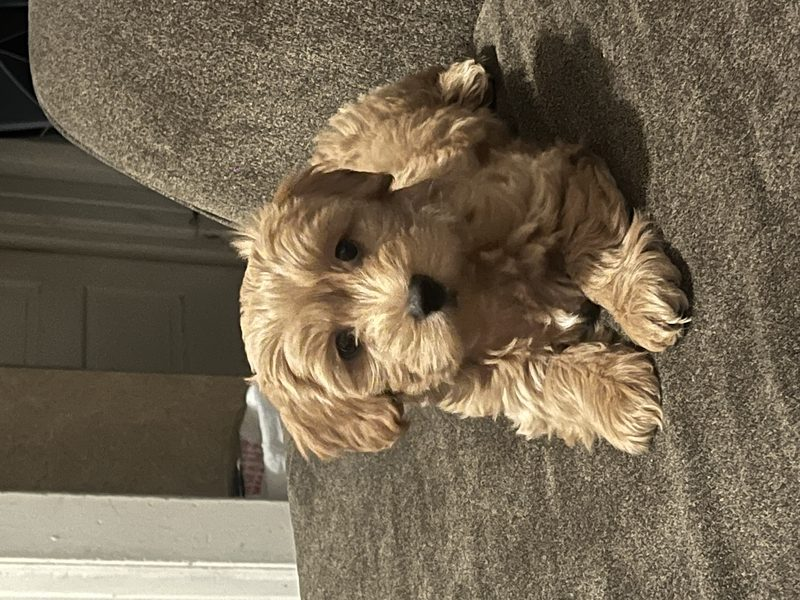
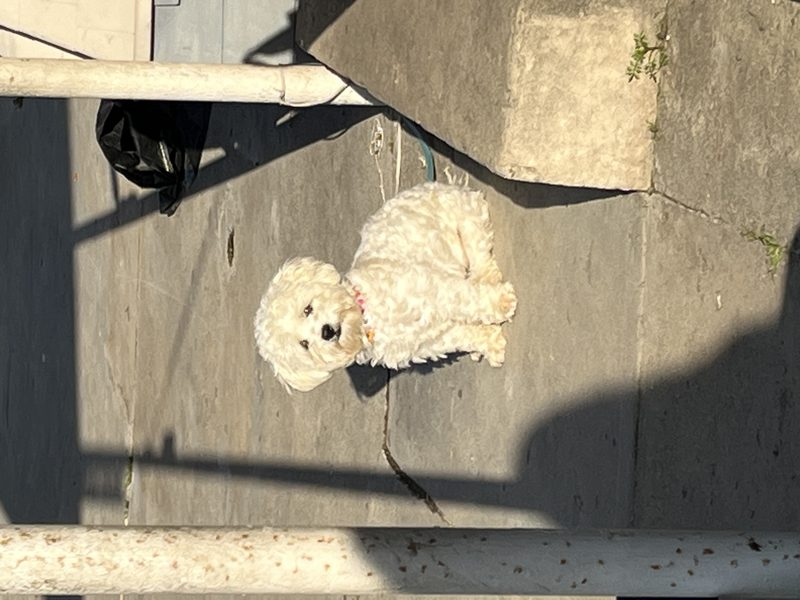

Congrats on finishing Homework 9!

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [ ]:
grader.check_all()

### Submission
1. Run `grader.check_all()` above and make sure all tests pass.
2. **File → Download → Download .ipynb**
3. Upload the `.ipynb` file to the LMS.

_(`grader.export()` does not work on Google Colab, so it has been removed.)_